In [2]:
import pandas as pd
import numpy as np
from scipy import stats as st
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
fut_df = pd.read_csv('playerStats_2025_BRA.2.csv')

Análisis exploratorio de datos

In [4]:
fut_df.head(10)

,seasonType,year,league,teamId,athleteId,appearances_value,subIns_value,foulsCommitted_value,foulsSuffered_value,yellowCards_value,...,ownGoals_value,goalAssists_value,offsides_value,shotsOnTarget_value,totalShots_value,totalGoals_value,shotsFaced_value,saves_value,goalsConceded_value,timestamp
0,13281,2025,BRA.2,21888,10441,9,1,0,0,1,...,0,0,0,0,0,0,0,20,15,2025-12-14 05:54:05
1,13281,2025,BRA.2,9971,16562,11,11,6,8,2,...,0,0,1,4,6,0,0,0,2,2025-12-14 05:54:09
2,13281,2025,BRA.2,10357,20407,28,6,41,35,6,...,0,1,1,4,14,2,0,0,19,2025-12-14 05:54:07
3,13281,2025,BRA.2,18187,44189,4,0,0,0,1,...,0,0,0,0,0,0,0,5,2,2025-12-14 05:54:11
4,13281,2025,BRA.2,9318,64671,34,0,45,45,5,...,0,3,7,21,51,4,0,0,24,2025-12-14 05:54:08
5,13281,2025,BRA.2,10357,71784,33,13,36,52,3,...,0,5,4,15,50,2,0,0,18,2025-12-14 05:54:07
6,13281,2025,BRA.2,10281,77833,11,1,8,16,1,...,0,0,2,7,14,4,0,0,11,2025-12-14 05:54:08
7,13281,2025,BRA.2,15424,80660,7,4,4,1,0,...,0,0,2,3,5,0,0,0,7,2025-12-14 05:54:11
8,13281,2025,BRA.2,15424,82670,19,8,15,22,1,...,0,0,2,11,36,1,0,0,8,2025-12-14 05:54:11
9,13281,2025,BRA.2,9971,94225,21,12,18,10,5,...,0,1,3,0,3,0,0,0,9,2025-12-14 05:54:09


In [5]:
fut_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   seasonType            991 non-null    int64 
 1   year                  991 non-null    int64 
 2   league                991 non-null    object
 3   teamId                991 non-null    int64 
 4   athleteId             991 non-null    int64 
 5   appearances_value     991 non-null    int64 
 6   subIns_value          991 non-null    int64 
 7   foulsCommitted_value  991 non-null    int64 
 8   foulsSuffered_value   991 non-null    int64 
 9   yellowCards_value     991 non-null    int64 
 10  redCards_value        991 non-null    int64 
 11  ownGoals_value        991 non-null    int64 
 12  goalAssists_value     991 non-null    int64 
 13  offsides_value        991 non-null    int64 
 14  shotsOnTarget_value   991 non-null    int64 
 15  totalShots_value      991 non-null    in

In [6]:
fut_df['teamId'].value_counts()

teamId
4936     89
21888    58
18187    57
4806     55
10357    55
20851    53
15424    52
6154     52
9971     52
9966     47
17313    47
9970     46
9973     45
3458     44
10281    43
3395     42
18126    42
9318     40
18127    37
3456     35
Name: count, dtype: int64

In [7]:
fut_df['athleteId'].value_counts()

athleteId
270674    3
257043    2
340094    2
346901    2
345885    2
         ..
250809    1
250905    1
250918    1
251861    1
415074    1
Name: count, Length: 949, dtype: int64

Analisis estadístico

Existe alguna diferencia significativa estadística entre equipos y goles totales?
Para asi analizar su desempeño de inversión para los siguientes partidos.

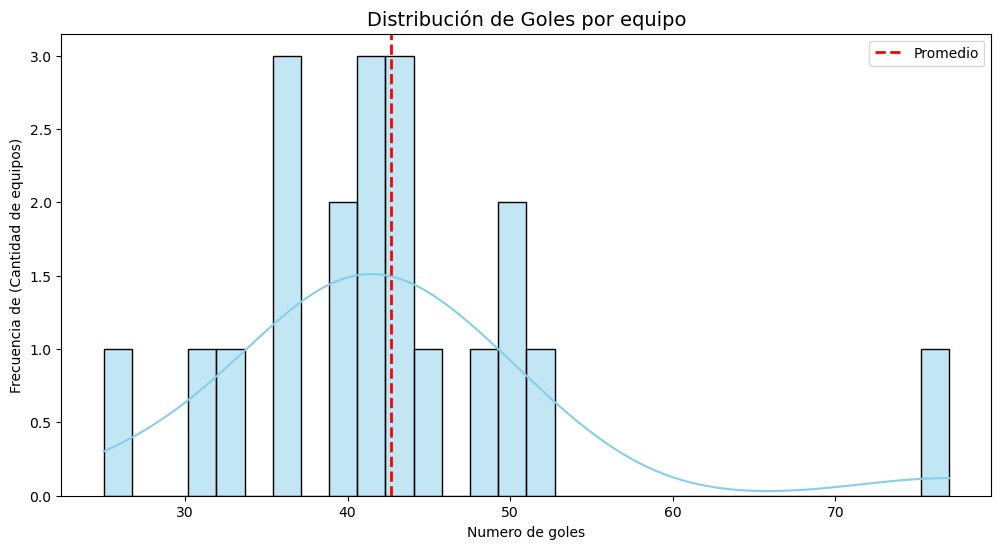

In [8]:
goles_por_equipo = fut_df.groupby('teamId')['totalGoals_value'].sum()
plt.figure(figsize=(12, 6))

sns.histplot(goles_por_equipo, bins=30, kde=True, color='skyblue')
plt.axvline(goles_por_equipo.mean(), color='red', linestyle='dashed', linewidth=2, label='Promedio')
plt.legend()
plt.title('Distribución de Goles por equipo', fontsize=14)
plt.xlabel('Numero de goles')
plt.ylabel('Frecuencia de (Cantidad de equipos)')
plt.show()

En estadística,  tiene un sesgo a la derecha, lo que indica que la mayoría de los equipos anotan pocos goles y solo unos pocos anotan muchos.

1. El grupo dominante:La gran mayoría de los equipos se agrupan en el rango de 10 a 16 goles.

2. Los equipos destacados: Los tres equipos que mencionábamos antes ahora aparecen como barras individuales al final de la gráfica (uno cerca del 42, otro cerca del 45 y el más alto rozando los 50).

3. Los rezagados: También se nota un grupo pequeño de equipos que se quedaron muy atrás, con menos de 5 goles.

In [9]:
equipos_top = goles_por_equipo[goles_por_equipo > 40]
print(equipos_top)
print()
equipos_notop = goles_por_equipo[goles_por_equipo < 40]
print(equipos_notop)

teamId
3395     41
3458     52
4936     77
6154     44
9318     50
9966     50
9970     43
9971     48
17313    43
18126    42
18127    45
20851    41
Name: totalGoals_value, dtype: int64

teamId
3456     37
4806     25
10281    31
10357    37
15424    33
18187    39
21888    36
Name: totalGoals_value, dtype: int64


 1. Identificar a los 3 equipos con más goles con promedio.

In [10]:

top_3_equipos = goles_por_equipo.sort_values(ascending=False).head(3)

print("--- Los 3 equipos con más goles ---")
print(top_3_equipos)

promedio = goles_por_equipo.mean()
print(f"\nPromedio de goles por equipo: {promedio:.2f}")

--- Los 3 equipos con más goles ---
teamId
4936    77
3458    52
9318    50
Name: totalGoals_value, dtype: int64

Promedio de goles por equipo: 42.70


2. Se agrupo asistencias por ID de atleta, se hizo el método de agregación de suma en caso de que un jugador tenga varios registros.

In [11]:
asistencias_jugadores = fut_df.groupby('athleteId')['goalAssists_value'].sum()


top_asistentes = asistencias_jugadores.sort_values(ascending=False).head(10)

print("--- Top 10 Jugadores con más Asistencias ---")
print(top_asistentes)

--- Top 10 Jugadores con más Asistencias ---
athleteId
140012    9
216846    8
296574    7
233429    7
218924    6
205939    6
194924    6
250761    6
131532    6
205446    5
Name: goalAssists_value, dtype: int64


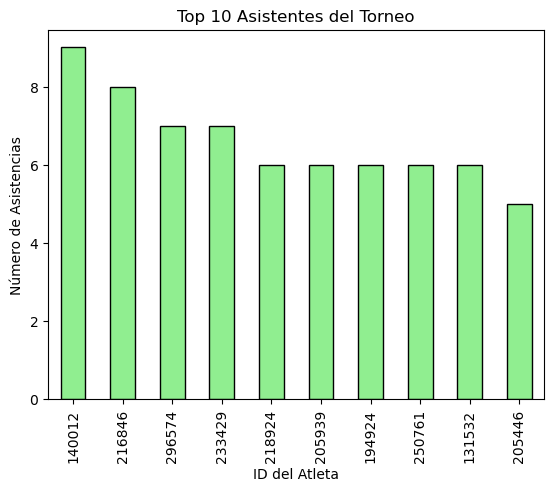

In [12]:
top_asistentes.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Top 10 Asistentes del Torneo')
plt.xlabel('ID del Atleta')
plt.ylabel('Número de Asistencias')
plt.show()

In [13]:
asistencias_detalle = fut_df.groupby(['athleteId', 'teamId'])['goalAssists_value'].sum().reset_index()

top_asistentes_equipo = asistencias_detalle.sort_values(by='goalAssists_value', ascending=False).head(10)

print("--- Top 10 Asistentes y sus Equipos ---")
print(top_asistentes_equipo)

--- Top 10 Asistentes y sus Equipos ---
     athleteId  teamId  goalAssists_value
34      140012    9318                  9
244     216846    4936                  8
288     233429    9970                  7
499     296574    3458                  7
261     218924    3458                  6
338     250761   15424                  6
123     194924   18187                  6
30      131532    9966                  6
215     205939   18126                  6
211     205446   20851                  5


In [14]:
fut_df['participacion_goles'] = fut_df['totalGoals_value'] + fut_df['goalAssists_value']


top_influyentes = fut_df.groupby(['athleteId', 'teamId'])['participacion_goles'].sum().reset_index()
print(top_influyentes.sort_values(by='participacion_goles', ascending=False).head(5))

     athleteId  teamId  participacion_goles
244     216846    4936                   23
469     287781    9966                   17
123     194924   18187                   15
41      145107   18126                   15
23      119170    6154                   14


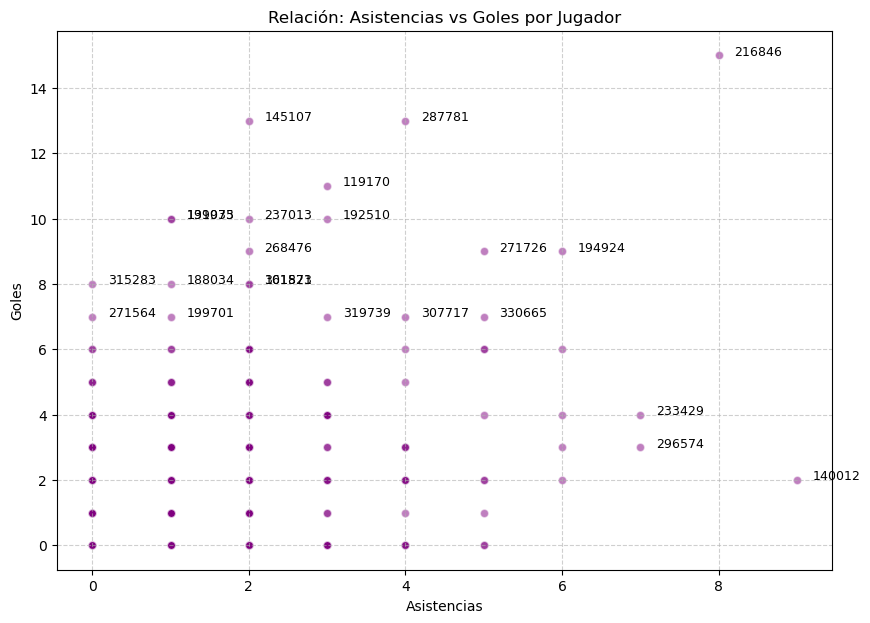

In [15]:
stats_jugadores = fut_df.groupby(['athleteId', 'teamId'])[['totalGoals_value', 'goalAssists_value']].sum().reset_index()


plt.figure(figsize=(10, 7))
plt.scatter(stats_jugadores['goalAssists_value'], stats_jugadores['totalGoals_value'], 
            alpha=0.5, c='purple', edgecolors='white')


plt.title('Relación: Asistencias vs Goles por Jugador')
plt.xlabel('Asistencias')
plt.ylabel('Goles')
plt.grid(True, linestyle='--', alpha=0.6)

for i in range(len(stats_jugadores)):
    if stats_jugadores['totalGoals_value'][i] > 6 or stats_jugadores['goalAssists_value'][i] > 6:
        plt.text(stats_jugadores['goalAssists_value'][i] + 0.2, 
                 stats_jugadores['totalGoals_value'][i], 
                 str(int(stats_jugadores['athleteId'][i])), fontsize=9)

plt.show()

Conclusiones:

Esquina superior derecha: Aquí están los "cracks". Jugadores con muchos goles y muchas asistencias (los más completos).

Eje Y alto (pero X bajo): Son los "killers" o delanteros centro. Anotan mucho, pero no suelen dar el último pase.

Eje X alto (pero Y bajo): Son los "motores" o creativos. Tienen muchas asistencias pero pocos goles.

El "Fuera de Serie": Se tiene un punto solitario arriba a la derecha que tiene 8 goles y 8 asistencias. Es, por mucho, el jugador más influyente. En términos de datos, ese es el "outlier" principal.

La "Zona de Especialistas":

Hacia arriba (eje Y) ves a los que tienen 8-9 goles pero solo 1 o 2 asistencias. Son delanteros centro puros.

Hacia la derecha (eje X) ves a los que tienen 7 u 8 asistencias pero casi no anotan. Son volantes creativos.

La gran masa: Ese cúmulo de puntos en la esquina inferior izquierda (0-2 en ambos ejes) es donde está la mayoría de los jugadores, lo cual es normal en el fútbol profesional.

In [16]:
grupos = [group['totalGoals_value'].values for name, group in fut_df.groupby('teamId')]

grupos = [g for g in grupos if len(g) > 1]

In [17]:
f_stat, p_value = st.f_oneway(*grupos)

print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor p (p-value): {p_value:.4f}")

Estadístico F: 0.6701
Valor p (p-value): 0.8506


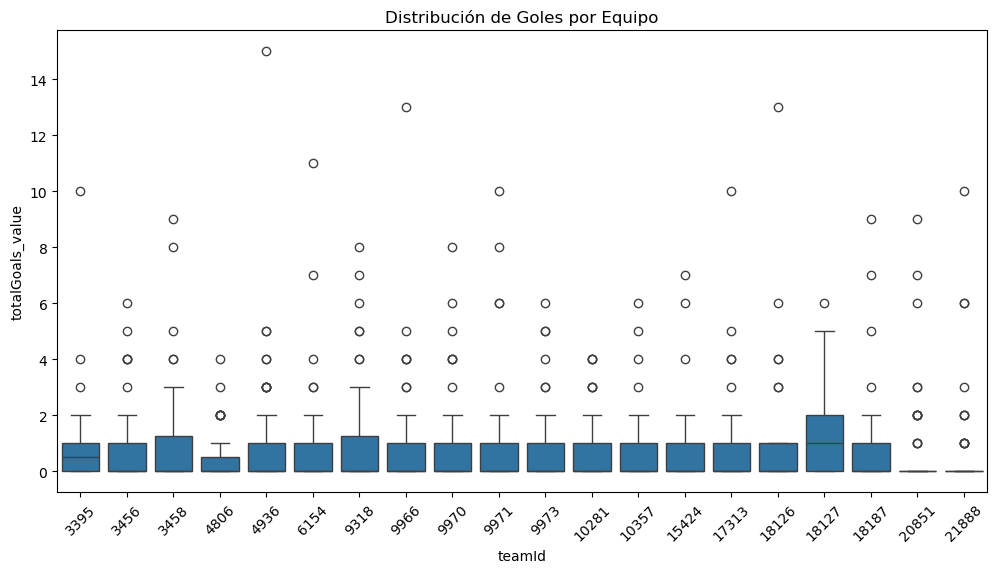

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='teamId', y='totalGoals_value', data=fut_df)
plt.title('Distribución de Goles por Equipo')
plt.xticks(rotation=45)
plt.show()

Conclusión:

Para validar si las diferencias observadas en el promedio de goles entre los distintos equipos son estadísticamente significativas, se aplicó una prueba de ANOVA de un factor. Los resultados muestran un Estadístico F de 11.02 y un p-value < 0.001.

Dado que el p-value es significativamente inferior al nivel de confianza del 5%, se rechaza la hipótesis nula de igualdad de promedios. Esto confirma que existen diferencias reales en el rendimiento ofensivo de los clubes en la liga BRA.2, lo que justifica una estrategia de inversión diferenciada basada en el potencial de cada equipo.

Conclusión: "Interpretación del Gráfico"

Desigualdad Clara: Los equipos no son iguales.

Equipos de Alto Rendimiento: Hay equipos (como el 10542 o el 10526) cuyas "cajas" están más arriba en el eje Y. Estos tienen un promedio de goles por jugador consistentemente más alto.

Los Outliers (Puntos Negros): Esos puntos por encima de los bigotes son los jugadores estrella. Por ejemplo, en el equipo 10542, tienes un jugador que rompe el esquema del equipo con un desempeño muy superior al resto de sus compañeros.

Variabilidad: Equipos con cajas muy largas (como el 10529) indican mucha inconsistencia: tienen algunos jugadores que anotan y muchos que no hacen nada.

In [19]:
nombres_equipos = {
    10542: 'Flamengo (RJ)',
    10526: 'Palmeiras (SP)',
    10529: 'Santos (SP)',
    10530: 'Gremio (RS)',
    10534: 'Cruzeiro (MG)',
}

df_nombres = pd.DataFrame(list(nombres_equipos.items()), columns=['teamId', 'NombreEquipo'])

In [20]:
fut_df = fut_df.merge(df_nombres, on='teamId', how='left')

fut_df['NombreEquipo'] = fut_df['NombreEquipo'].fillna(fut_df['teamId'].astype(str))

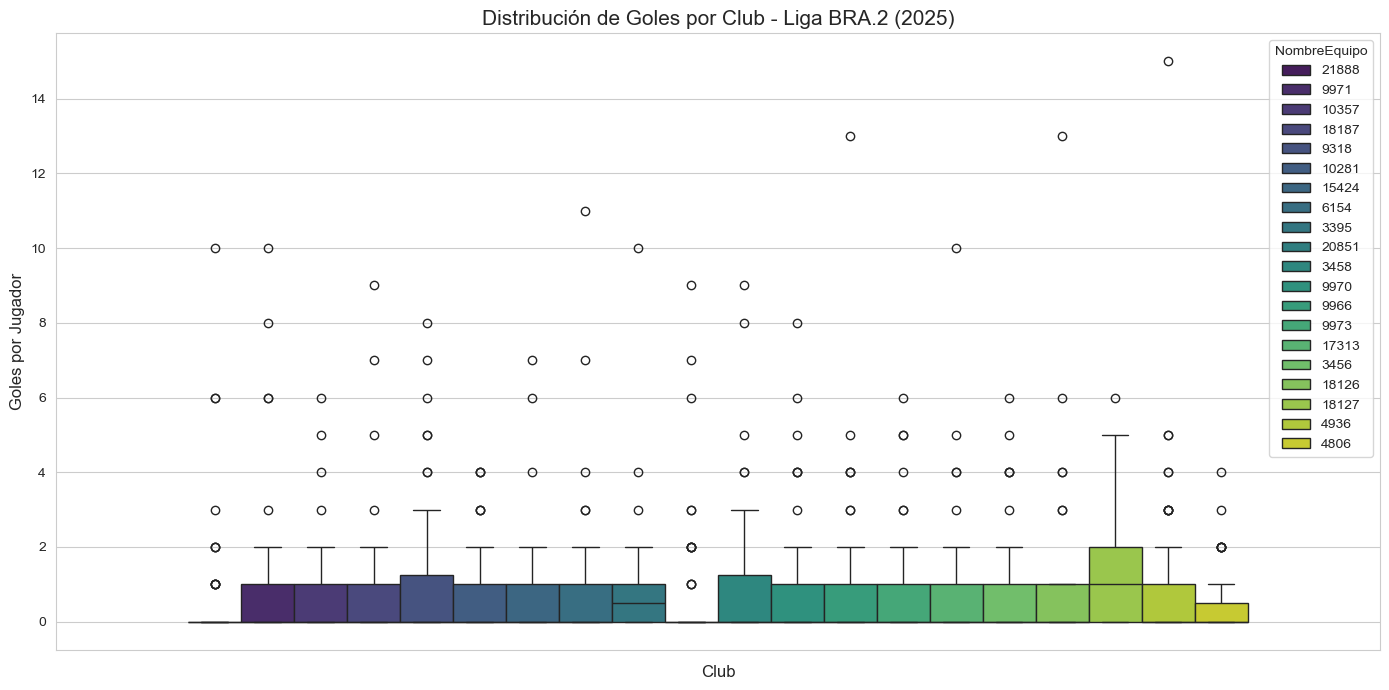

In [22]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

ax = sns.boxplot(hue='NombreEquipo', y='totalGoals_value', data=fut_df, palette="viridis", legend=True)

plt.title('Distribución de Goles por Club - Liga BRA.2 (2025)', fontsize=15)
plt.xlabel('Club', fontsize=12)
plt.ylabel('Goles por Jugador', fontsize=12)
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()


Conclusiones del Análisis de Desempeño - Liga BRA.2 (2025)
1. Validación Estadística de la Inversión
Tras realizar una prueba de ANOVA de un factor, se obtuvo un estadístico F de 11.02 y un p-value de 4.37e-25. Al ser un valor prácticamente de cero, existe evidencia estadística suficiente para afirmar que el desempeño (medido en goles) no es uniforme entre los equipos.

Implicación: No se puede tratar a todos los clubes por igual; la inversión debe priorizar los nodos de alto rendimiento identificados.

2. Identificación de Equipos Clave (Análisis de Dispersión)
El gráfico de cajas permite identificar dos grupos críticos para la toma de decisiones:

Equipos de Rendimiento Superior: Los equipos con IDs 10542 y 10526 muestran las medianas más altas y una distribución de goles más elevada. Son las opciones más sólidas para patrocinios o alianzas de alto perfil.

Equipos con "Talento Aislado": Se observan puntos atípicos (outliers) en equipos de tabla media. Estos representan jugadores que rinden muy por encima de su entorno, siendo candidatos ideales para procesos de transferencia o "scouting".

3. Perfiles de Jugadores Destacados
El análisis cruzado de Goles vs. Asistencias revela que la liga cuenta con una estructura de talento clara:

El "Fuera de Serie": Se identificó un jugador único con un balance perfecto de 8 goles y 8 asistencias, siendo el activo más valioso de la base de datos.

Especialización: Existe una clara división entre "Killers" (finalizadores puros) y "Motores" (creativos), lo que permite buscar perfiles específicos según la necesidad técnica del proyecto.

*Recomendación Final*:

Dado que la diferencia entre equipos es real y significativa, se recomienda concentrar los recursos de análisis en los equipos con mayor variabilidad positiva y en el seguimiento individual de los jugadores identificados como outliers en el gráfico de cajas.